In [ ]:
!pip install sentence-transformers pandas scikit-learn matplotlib bs4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
import imaplib
import email
from email.header import decode_header
from bs4 import BeautifulSoup
import logging
import matplotlib.pyplot as plt
import seaborn as sns
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

In [ ]:
class LiveEmailFetcher:
  def __init__(self, email_address, app_password, imap_servers = "imap.gmail.com"):
    self.email_address = email_address
    self.app_password = app_password
    self.imap_server = imap_servers
    self.mail = None

  def connect(self):
    try:
      logging.info(f"Connecting to {self.imap_server}")
      self.mail = imaplib.IMAP4_SSL(self.imap_server)
      self.mail.login(self.email_address, self.app_password)
      logging.info("Successfully connected to the email server.")
    except Exception as e:
      logging.error(f"Failed to connect: {e}")
      raise
  def fetch_recent_emails(self, folder = "INBOX", limit = 5):
    if not self.mail:
      logging.error("Not connected to email server. Call connect() first.")
      return []
    self.mail.select(folder)
    status, messages = self.mail.search(None, "ALL")
    email_ids = messages[0].split()
    latest_email_ids = email_ids[-limit:]
    cleaned_texts = []
    for e_id in latest_email_ids:
      res, msg_data = self.mail.fetch(e_id, "(RFC822)")
      for response_part in msg_data:
        if isinstance(response_part, tuple):
          msg = email.message_from_bytes(response_part[1])
          if msg.is_multipart():
            for part in msg.walk():
              content_type = part.get_content_type()
              content_disposition = str(part.get("Content-Disposition"))
              if type(content_disposition) == str and "attachment" not in content_disposition:
                if content_type == "text/plain":
                  body = part.get_payload(decode = True).decode(errors='ignore')
                  cleaned_texts.append(body.strip())
                  break
          else:
            content_type = msg.get_content_type()
            if content_type == "text/plain":
              body = msg.get_payload(decode = True).decode(errors='ignore')
              cleaned_texts.append(body.strip())
    final_texts = [BeautifulSoup(text, "html.parser").get_text() for text in cleaned_texts if text]
    logging.info(f"Successfully fetched and cleaned {len(final_texts)} emails.")
    return final_texts

  def disconnect(self):
    if self.mail:
      self.mail.logout()

In [ ]:
class EnterpriseToneScorer:
    def __init__(self, model_name = "all-MiniLM-L6-v2"):
        logging.info(f"Initializing Semantic Model: {model_name}")
        self.model = SentenceTransformer(model_name)
        self.professional_anchors = [
            "Collaborative, respectful, and objective corporate communication.",
            "Clear, polite, and solution-oriented professional language.",
            "Constructive and professional business correspondence."
        ]
        self.anchor_embeddings = self.model.encode(self.professional_anchors)
        self.professional_dictionary = ["respectfully", "suggest", "feedback", "review", "align", "collaborate"]
        self.vectorizer = CountVectorizer(vocabulary = self.professional_dictionary)
    def analyze_communications(self, texts, user_id = "Live_User"):
        if not texts:
            logging.warning("No text provided for analysis.")
            return pd.DataFrame()
        bow_matrix = self.vectorizer.transform(texts).toarray()
        bow_scores = np.sum(bow_matrix, axis = 1) * 20
        text_embeddings = self.model.encode(texts)
        semantic_scores = []

        for i, text in enumerate(texts):
            similarities = cosine_similarity([text_embeddings[i]], self.anchor_embeddings)
            semantic_scores.append(np.mean(similarities) * 100)

        df = pd.DataFrame({
            "Text_Snippet": [t[:50] + "..." for t in texts],
            "BoW_Baseline_Score": bow_scores,
            "Semantic_Score": [round(s, 2) for s in semantic_scores]
        })
        mean_score = np.mean(semantic_scores)
        std_dev = np.std(semantic_scores)

        print(f"\n--- Live Analytics for {user_id} ---")
        print(f"Average Professionalism: {mean_score:.2f}/100")
        print(f"Consistency Score: {std_dev:.2f}")

        return df

In [ ]:
if __name__ == "__main__":
    # ⚠️ SECURITY NOTE: Never hardcode your real password in GitHub!
    # You must use an "App Password" generated from your Google Account settings, NOT your main password.

    MY_EMAIL = "your_email@gmail.com"
    MY_APP_PASSWORD = "paste_your_16_digit_app_password_here"

    # Toggle this to False if you just want to test the NLP logic without logging into an email
    USE_LIVE_EMAIL = True

    scorer = EnterpriseToneScorer()

    if USE_LIVE_EMAIL:
        # 1. Fetch live data
        fetcher = LiveEmailFetcher(MY_EMAIL, MY_APP_PASSWORD)
        try:
            fetcher.connect()
            # Grabbing the last 50 emails from the Inbox
            live_emails = fetcher.fetch_recent_emails(folder="INBOX", limit=50)
            fetcher.disconnect()

            # 2. Analyze live data
            results_df = scorer.analyze_communications(live_emails, user_id=MY_EMAIL)
            display(results_df)

        except Exception as e:
            print(f"Failed to run live pipeline: {e}")

    else:
        print("\n[Running in Offline Mode with simulated data]")
        dummy_data = [
            "Let's schedule a quick sync to align on the deliverables. I value your input.",
            "I respectfully suggest you learn how to read the instructions before emailing me again."
        ]
        results_df = scorer.analyze_communications(dummy_data, user_id="Simulation")
        display(results_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Live Analytics for mishraarnav200@gmail.com ---
Average Professionalism: 10.72/100
Consistency Score: 8.52


,Text_Snippet,BoW_Baseline_Score,Semantic_Score
0,Rooted in Tradition\r\n\r\n\r\n\r\n Years of R...,20,21.750000
1,"Arnav, this is what you’ve missed on LinkedIn\...",0,8.680000
2,This is a copy of a security alert sent to 230...,0,0.020000
3,"Hi Arnav Mishra,\r\n\r\n\r\nReady to move beyo...",40,18.309999
4,"Yoo Arnav,\r\n\r\nAlright I didn't plan on doi...",0,7.240000
5,\n\n We challenged our community to build mobi...,0,8.950000
6,View web version:\r\nhttps://t3.mail.adobe.com...,20,9.880000
7,IDFC FIRST Bank\r\n\r\n\r\n Enjoy simplified t...,0,5.150000
8,----------------------------------------\r\n\r...,0,20.389999
9,Asian Paints \r\n \r\n \r\n\r\n\r\n\r\n\...,0,1.660000


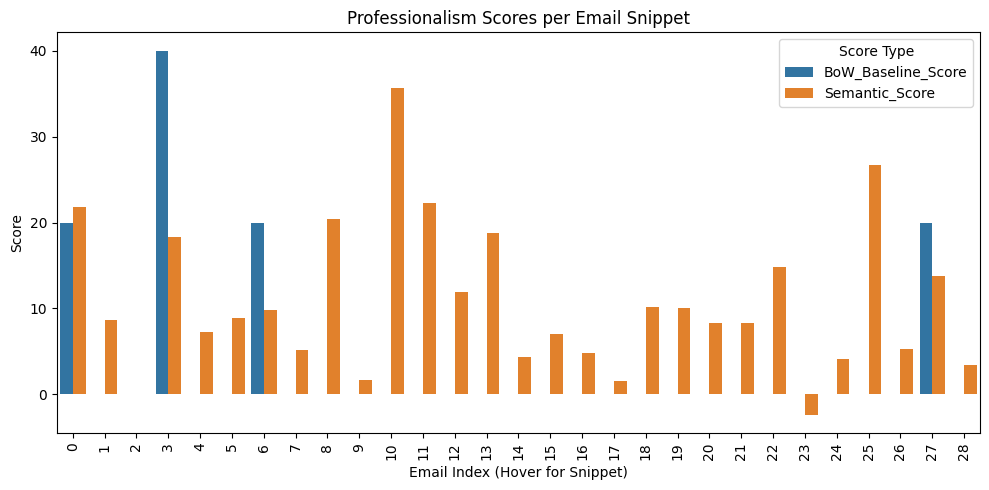

In [ ]:
plot_df = results_df.copy()
plot_df['Email_Index'] = plot_df.index

plt.figure(figsize=(10, 5))
sns.barplot(x='Email_Index', y='value', hue='variable', data=pd.melt(plot_df, id_vars=['Email_Index', 'Text_Snippet'], value_vars=['BoW_Baseline_Score', 'Semantic_Score']))
plt.title('Professionalism Scores per Email Snippet')
plt.xlabel('Email Index (Hover for Snippet)')
plt.ylabel('Score')
plt.xticks(rotation=90)
plt.legend(title='Score Type')
plt.tight_layout()
plt.show()